# Single variate time series forecasts

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from warnings import filterwarnings

filterwarnings('ignore')

In [136]:
df = pd.read_csv('../data/jena_climate_2009_2016.csv')
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [137]:
df.index = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:10:00,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 23:20:00,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
2016-12-31 23:30:00,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
2016-12-31 23:40:00,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,,
2009-01-01 01:00:00,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.40,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 02:00:00,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.20,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2009-01-01 03:00:00,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.50,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
2009-01-01 04:00:00,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.60,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
2009-01-01 05:00:00,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.20,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:10:00,31.12.2016 19:10:00,1002.18,-0.98,272.01,-5.36,72.00,5.69,4.09,1.59,2.54,4.08,1280.70,0.87,1.36,190.6
2016-12-31 20:10:00,31.12.2016 20:10:00,1001.40,-1.40,271.66,-6.84,66.29,5.51,3.65,1.86,2.27,3.65,1281.87,1.02,1.92,225.4
2016-12-31 21:10:00,31.12.2016 21:10:00,1001.19,-2.75,270.32,-6.90,72.90,4.99,3.64,1.35,2.26,3.63,1288.02,0.71,1.56,158.7


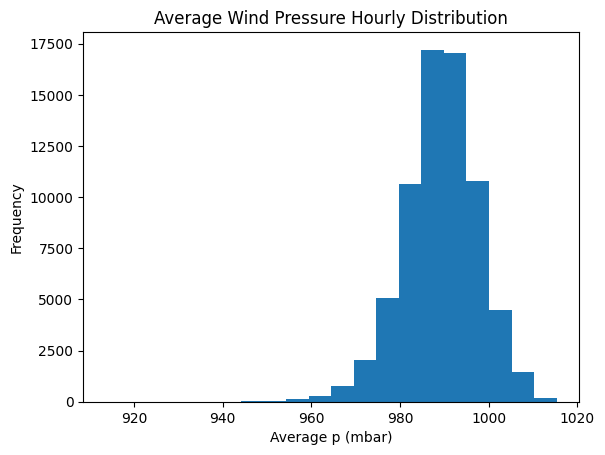

In [138]:
hourly_ts = df[5::6]
hourly_ts['p (mbar)'].plot(kind='hist', bins = 20, title='Average Wind Pressure Hourly Distribution', xlabel='Average p (mbar)')
hourly_ts

## Selecting single variable

<Axes: xlabel='Date Time'>

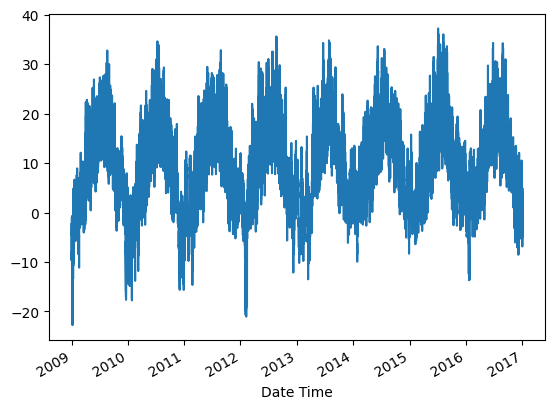

In [139]:
temp = hourly_ts['T (degC)']
temp.plot()

## Creating sequence

In [140]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df: pd.DataFrame, window_size=5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np)-window_size):
        row = [[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label = df_as_np[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)

In [141]:
WINDOW_SIZE = 5
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X1.shape, y1.shape

((70086, 5, 1), (70086,))

## Train test split

In [142]:
X_train1, y_train1 = X1[:60000], y1[:60000]
X_val1, y_val1 = X1[60000:65000], y1[60000:65000]
X_test1, y_test1 = X1[65000:], y1[65000:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((60000, 5, 1), (60000,), (5000, 5, 1), (5000,), (5086, 5, 1), (5086,))

## Using LSTM

In [143]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import LSTM, Dense, InputLayer

### Creating LSTM NN

In [144]:
model1 = Sequential()
model1.add(InputLayer((5, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

### Saving and compiling for best model

In [86]:
check_point = ModelCheckpoint('../model/model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

### Fit on model

In [87]:
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[check_point])

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 81.0704 - root_mean_squared_error: 8.8409 - val_loss: 1.5170 - val_root_mean_squared_error: 1.2317
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 3.9831 - root_mean_squared_error: 1.9828 - val_loss: 0.6687 - val_root_mean_squared_error: 0.8177
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 1.2556 - root_mean_squared_error: 1.1184 - val_loss: 0.5449 - val_root_mean_squared_error: 0.7382
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.8002 - root_mean_squared_error: 0.8944 - val_loss: 0.5177 - val_root_mean_squared_error: 0.7195
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.7164 - root_mean_squared_error: 0.8463 - val_loss: 0.5153 - val_root_mean_squared_error: 0.7179
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.6764 - root_mean_squared_error: 0.8224 - val_loss: 0.4929 - val_root_mean_squared_error: 0.7020
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10

### Loading best model

In [88]:
from tensorflow.keras.models import load_model

model_1 = load_model('../model/model1.keras')
model_1

<Sequential name=sequential_5, built=True>

### Predicting and plotting

In [89]:
train_predictions = model_1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


,Train Predictions,Actuals
0,-9.909493,-9.67
1,-9.729877,-9.17
2,-8.847322,-8.10
3,-7.300622,-7.66
4,-7.157130,-7.04
...,...,...
59995,5.962856,6.07
59996,7.066924,9.88
59997,12.287158,13.53
59998,16.061924,15.43


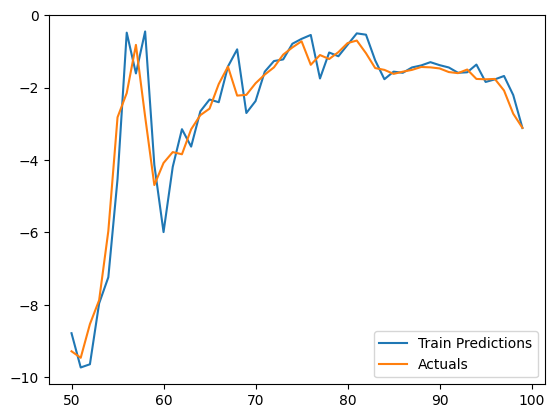

In [90]:
plt.plot(train_results['Train Predictions'][50:100], label='Train Predictions')
plt.plot(train_results['Actuals'][50:100], label='Actuals')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


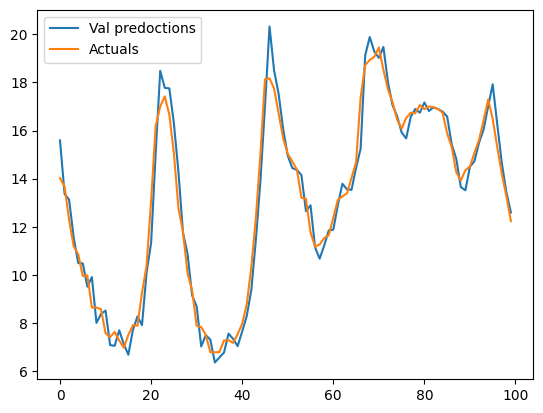

,Val Predictions,Actuals
0,15.587973,14.02
1,13.366433,13.67
2,13.121049,12.27
3,11.549604,11.19
4,10.492758,10.85
...,...,...
4995,17.406281,18.27
4996,17.461325,17.85
4997,17.311296,16.65
4998,16.011797,15.85


In [91]:
val_predictions = model1.predict(X_val1).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1})

plt.plot(val_results['Val Predictions'][:100], label='Val predoctions')
plt.plot(val_results['Actuals'][:100], label = 'Actuals')
plt.legend()
plt.show()

val_results

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


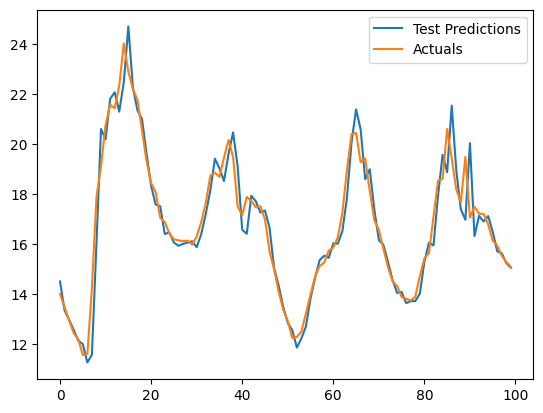

,Test Predictions,Actuals
0,14.493172,13.99
1,13.336514,13.46
2,12.959322,12.93
3,12.556342,12.43
4,12.125244,12.17
...,...,...
5081,-1.170913,-0.98
5082,-1.489272,-1.40
5083,-1.670150,-2.75
5084,-3.392990,-2.89


In [92]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})

plt.plot(test_results['Test Predictions'][:100], label='Test Predictions')
plt.plot(test_results['Actuals'][:100], label='Actuals')
plt.legend()
plt.show()

test_results

## Using Conv1D

In [145]:
from tensorflow.keras.layers import Conv1D, Dense, Flatten
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

### Creating Conv1D sequence

In [94]:
conv_model = Sequential()
conv_model.add(InputLayer((5, 1)))
conv_model.add(Conv1D(64, kernel_size=2))
conv_model.add(Flatten())
conv_model.add(Dense(8, "relu"))
conv_model.add(Dense(1, "linear"))

conv_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 4, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │         2,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257 (8.82 KB)

 Trainable params: 2,257 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling conv1d layer

In [95]:
conv_check_point = ModelCheckpoint('../model/conv1d_best_model.keras', save_best_only=True)
conv_model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

### Training and saving best model

In [96]:
conv_history = conv_model.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), callbacks=[conv_check_point], epochs=10)

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 21.5155 - root_mean_squared_error: 4.2494 - val_loss: 1.0541 - val_root_mean_squared_error: 1.0267
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.1876 - root_mean_squared_error: 1.0891 - val_loss: 0.7024 - val_root_mean_squared_error: 0.8381
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.8571 - root_mean_squared_error: 0.9256 - val_loss: 0.5525 - val_root_mean_squared_error: 0.7433
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7060 - root_mean_squared_error: 0.8401 - val_loss: 0.5311 - val_root_mean_squared_error: 0.7288
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6942 - root_mean_squared_error: 0.8331 - val_loss: 0.5471 - val_root_mean_squared_error: 0.7397
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6613 - root_mean_squared_error: 0.8131 - val_loss: 0.5194 - val_root_mean_squared_error: 0.7207
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/s

### Predicting and visualizing

In [97]:
from numpy.typing import ArrayLike

def predict_plot(
    X_input: ArrayLike,
    y_actual: ArrayLike,
    model,
    title = 'Predictions vs Actuals',
    start=0,
    end=100
):
    predicted = model.predict(X_input).flatten()
    df = pd.DataFrame(data={'predicted': predicted, 'y_actual': y_actual})
    df.iloc[start:end].plot(title=title)
    return df

### loading saved model and plotting

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,predicted,y_actual
0,14.090661,13.99
1,12.943265,13.46
2,12.638915,12.93
3,12.238034,12.43
4,11.838085,12.17
...,...,...
5081,-1.149165,-0.98
5082,-1.492124,-1.40
5083,-1.713196,-2.75
5084,-3.038044,-2.89


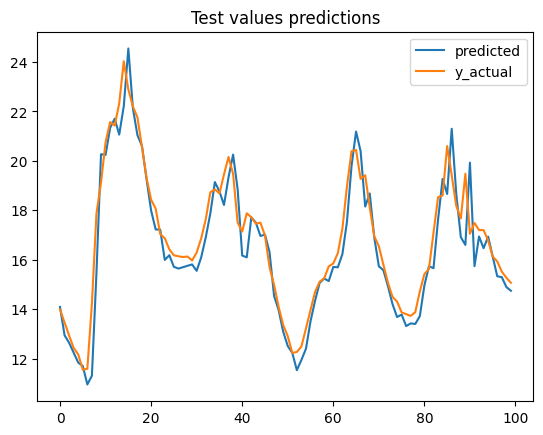

In [98]:
best_conv_model = load_model('../model/conv1d_best_model.keras')

predict_plot(
    X_input=X_test1,
    y_actual=y_test1,
    model=best_conv_model,
    title='Test values predictions'
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,predicted,y_actual
0,15.216193,14.02
1,12.737586,13.67
2,12.795339,12.27
3,11.309191,11.19
4,10.289060,10.85
...,...,...
4995,16.898947,18.27
4996,17.159451,17.85
4997,16.887112,16.65
4998,15.656484,15.85


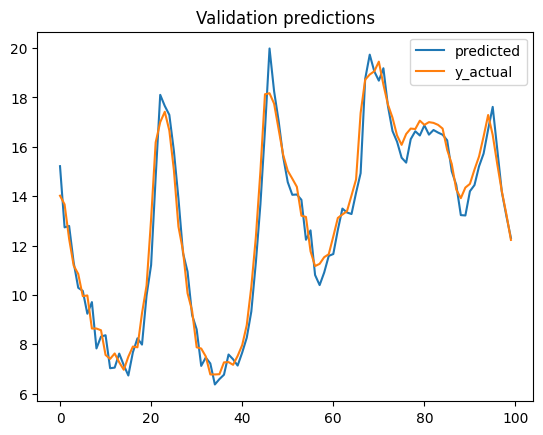

In [99]:
predict_plot(
    X_input=X_val1,
    y_actual=y_val1,
    model=best_conv_model,
    title='Validation predictions'
)

## Using GRU

In [146]:
from tensorflow.keras.layers import GRU

### Creating GRU layer

In [101]:
gru_model = Sequential()
gru_model.add(InputLayer((5, 1)))
gru_model.add(GRU(64))
gru_model.add(Dense(8, "relu"))
gru_model.add(Dense(1, "linear"))
gru_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,393 (52.32 KB)

 Trainable params: 13,393 (52.32 KB)

 Non-trainable params: 0 (0.00 B)

### Best model checkpoint and compilation

In [102]:
gru_check_point = ModelCheckpoint('../model/gru_best_model.keras', save_best_only=True)
gru_model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

### Training and getting best GRU model

In [103]:
gru_history = gru_model.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), callbacks=[gru_check_point], epochs=10)

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 69.3883 - root_mean_squared_error: 8.1254 - val_loss: 1.2010 - val_root_mean_squared_error: 1.0959
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 3.2029 - root_mean_squared_error: 1.7806 - val_loss: 0.6365 - val_root_mean_squared_error: 0.7978
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.1000 - root_mean_squared_error: 1.0479 - val_loss: 0.5252 - val_root_mean_squared_error: 0.7247
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.7667 - root_mean_squared_error: 0.8754 - val_loss: 0.5149 - val_root_mean_squared_error: 0.7176
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.6800 - root_mean_squared_error: 0.8244 - val_loss: 0.4953 - val_root_mean_squared_error: 0.7038
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6578 - root_mean_squared_error: 0.8110 - val_loss: 0.5037 - val_root_mean_squared_error: 0.7097
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11

### Predicting and plotting

#### loading best model, predicting and plotting

159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


,predicted,y_actual
0,14.435660,13.99
1,13.250821,13.46
2,12.905210,12.93
3,12.460298,12.43
4,12.022334,12.17
...,...,...
5081,-1.248961,-0.98
5082,-1.413890,-1.40
5083,-1.440432,-2.75
5084,-3.307476,-2.89


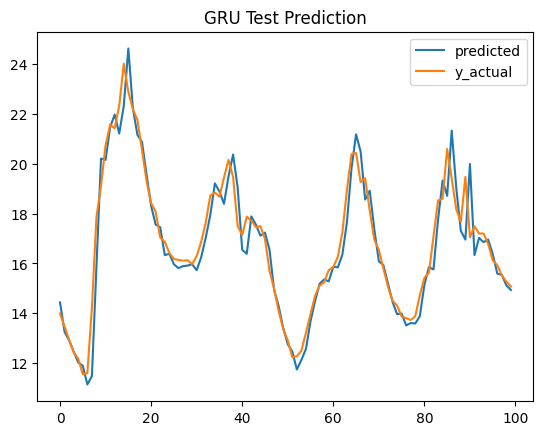

In [104]:
best_gru_model = load_model('../model/gru_best_model.keras')

predict_plot(X_input=X_test1, y_actual=y_test1, model=best_gru_model, title='GRU Test Prediction')

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


,predicted,y_actual
0,15.474118,14.02
1,13.240514,13.67
2,13.118508,12.27
3,11.447885,11.19
4,10.406253,10.85
...,...,...
4995,17.528973,18.27
4996,17.400438,17.85
4997,17.317381,16.65
4998,15.909412,15.85


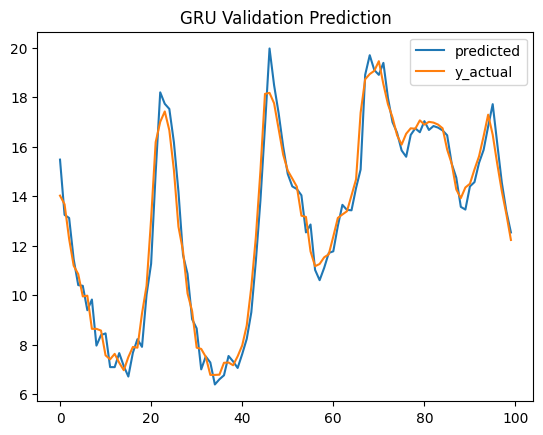

In [105]:
predict_plot(X_input=X_val1, y_actual=y_val1, model=best_gru_model, title='GRU Validation Prediction')

# Multi-variate time series forecasting

## Using LSTM

### Data preparation

In [147]:
temp_df = pd.DataFrame(data={'Temperature': temp})
temp_df['seconds'] = temp_df.index.map(pd.Timestamp.timestamp)
temp_df

,Temperature,seconds
Date Time,,
2009-01-01 01:00:00,-8.05,1.230772e+09
2009-01-01 02:00:00,-8.88,1.230775e+09
2009-01-01 03:00:00,-8.81,1.230779e+09
2009-01-01 04:00:00,-9.05,1.230782e+09
2009-01-01 05:00:00,-9.63,1.230786e+09
...,...,...
2016-12-31 19:10:00,-0.98,1.483211e+09
2016-12-31 20:10:00,-1.40,1.483215e+09
2016-12-31 21:10:00,-2.75,1.483219e+09


In [148]:
day_seconds = 60*60*24
year_seconds = 365 * day_seconds

temp_df['Day sine'] = np.sin(temp_df['seconds'] * (2 * np.pi / day_seconds))
temp_df['Day cos'] = np.cos(temp_df['seconds'] * (2 * np.pi / day_seconds))
temp_df['Year sine'] = np.sin(temp_df['seconds'] * (2 * np.pi / day_seconds))
temp_df['Year cos'] = np.cos(temp_df['seconds'] * (2 * np.pi / day_seconds))

temp_df.drop(axis=1, labels='seconds', inplace=True)

temp_df

,Temperature,Day sine,Day cos,Year sine,Year cos
Date Time,,,,,
2009-01-01 01:00:00,-8.05,0.258819,0.965926,0.258819,0.965926
2009-01-01 02:00:00,-8.88,0.500000,0.866025,0.500000,0.866025
2009-01-01 03:00:00,-8.81,0.707107,0.707107,0.707107,0.707107
2009-01-01 04:00:00,-9.05,0.866025,0.500000,0.866025,0.500000
2009-01-01 05:00:00,-9.63,0.965926,0.258819,0.965926,0.258819
...,...,...,...,...,...
2016-12-31 19:10:00,-0.98,-0.953717,0.300706,-0.953717,0.300706
2016-12-31 20:10:00,-1.40,-0.843391,0.537300,-0.843391,0.537300
2016-12-31 21:10:00,-2.75,-0.675590,0.737277,-0.675590,0.737277


In [149]:
def multi_var_X_Y(df: pd.DataFrame, window_size=6):
    df_numpy = df.to_numpy()
    X = []
    Y = []

    for i in range(len(df_numpy) - window_size):
        row = [x for x in df_numpy[i : i + window_size]]
        X.append(row)
        label = df_numpy[i + window_size][0]
        Y.append(label)

    return np.array(X), np.array(Y)

In [150]:
X2, y2 = multi_var_X_Y(df=temp_df)
X2.shape, y2.shape

((70085, 6, 5), (70085,))

### Train, test, validation split

In [151]:
X2_train, y2_train = X2[:60000], y2[:60000]
X2_val, y2_val = X2[60000:65000], y2[60000:65000]
X2_test, y2_test = X2[65000:], y2[65000:]
X2_train.shape, y2_train.shape, X2_val.shape, y2_val.shape, X2_test.shape, y2_test.shape

((60000, 6, 5), (60000,), (5000, 6, 5), (5000,), (5085, 6, 5), (5085,))

### Standardizing X

In [152]:
temp_training_mean = np.mean(X2_train[:, :, 0])
temp_training_std = np.std(X2_train[:, :, 0])

def preprocess(X):
    X[:, :, 0] = (X[:, :, 0] - temp_training_mean) / temp_training_std
    return X

In [153]:
preprocess(X2_train), preprocess(X2_val), preprocess(X2_test)

(array([[[-2.05339708e+00,  2.58819045e-01,  9.65925826e-01,
           2.58819045e-01,  9.65925826e-01],
         [-2.15095027e+00,  5.00000000e-01,  8.66025404e-01,
           5.00000000e-01,  8.66025404e-01],
         [-2.14272289e+00,  7.07106781e-01,  7.07106781e-01,
           7.07106781e-01,  7.07106781e-01],
         [-2.17093105e+00,  8.66025404e-01,  5.00000000e-01,
           8.66025404e-01,  5.00000000e-01],
         [-2.23910075e+00,  9.65925826e-01,  2.58819045e-01,
           9.65925826e-01,  2.58819045e-01],
         [-2.24380211e+00,  1.00000000e+00,  4.33995489e-12,
           1.00000000e+00,  4.33995489e-12]],
 
        [[-2.15095027e+00,  5.00000000e-01,  8.66025404e-01,
           5.00000000e-01,  8.66025404e-01],
         [-2.14272289e+00,  7.07106781e-01,  7.07106781e-01,
           7.07106781e-01,  7.07106781e-01],
         [-2.17093105e+00,  8.66025404e-01,  5.00000000e-01,
           8.66025404e-01,  5.00000000e-01],
         [-2.23910075e+00,  9.65925826e-01,

### Creating multi-var LSTM layer

In [154]:
multi_lstm = Sequential()
multi_lstm.add(InputLayer((6, 5)))
multi_lstm.add(LSTM(64))
multi_lstm.add(Dense(8, "relu"))
multi_lstm.add(Dense(1, "linear"))
multi_lstm.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,449 (72.07 KB)

 Trainable params: 18,449 (72.07 KB)

 Non-trainable params: 0 (0.00 B)

### Saving and compiling for best model

In [155]:
multi_check_point = ModelCheckpoint("../model/lstm_multi_best_model.keras", save_best_only=True)
multi_lstm.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

### Training

In [156]:
multi_history_lstm = multi_lstm.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=10, callbacks=[multi_check_point])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 89.1569 - root_mean_squared_error: 9.1975 - val_loss: 4.5951 - val_root_mean_squared_error: 2.1436
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 6.3023 - root_mean_squared_error: 2.5042 - val_loss: 2.5167 - val_root_mean_squared_error: 1.5864
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - loss: 2.7117 - root_mean_squared_error: 1.6449 - val_loss: 1.2131 - val_root_mean_squared_error: 1.1014
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 1.4341 - root_mean_squared_error: 1.1966 - val_loss: 0.8394 - val_root_mean_squared_error: 0.9162
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.9973 - root_mean_squared_error: 0.9984 - val_loss: 0.6447 - val_root_mean_squared_error: 0.8030
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.7644 - root_mean_squared_error: 0.8742 - val_loss: 0.5138 - val_root_mean_squared_error: 0.7168
Epoch 7/10
1875/1875 ━━━━━━━━━━

### Loading saved best model

In [159]:
best_multi_lstm = load_model("../model/lstm_multi_best_model.keras")

### Predicting and plotting

159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


,predicted,y_actual
0,13.195995,13.46
1,12.763279,12.93
2,12.303749,12.43
3,11.919616,12.17
4,11.955479,11.55
...,...,...
5080,-1.115972,-0.98
5081,-1.367428,-1.40
5082,-1.634496,-2.75
5083,-3.070260,-2.89


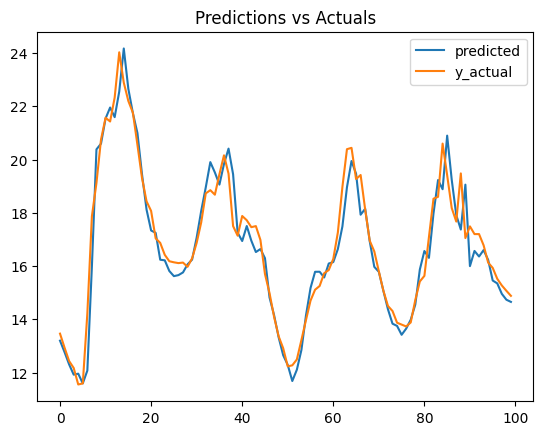

In [160]:
predict_plot(X_input=X2_test, y_actual=y2_test, model=best_multi_lstm)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


,predicted,y_actual
0,13.119895,13.67
1,12.907503,12.27
2,11.312045,11.19
3,10.300557,10.85
4,10.248935,9.95
...,...,...
4995,17.148714,17.85
4996,16.891054,16.65
4997,15.784656,15.85
4998,15.043244,15.09


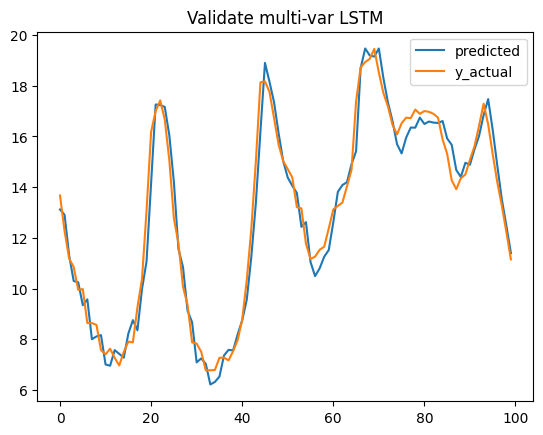

In [161]:
predict_plot(X_input=X2_val, y_actual=y2_val, model=best_multi_lstm, title='Validate multi-var LSTM')

## Using Conv1D

### Data preparation

In this case and that onwards, I am going to include to variables/time series, in order to train on them and also forecast on them. These two series are that of `Temperature` and `p (mbar)` respectively.

In [162]:
p_temp_df = pd.concat([hourly_ts['p (mbar)'], temp_df], axis=1)
p_temp_df

,p (mbar),Temperature,Day sine,Day cos,Year sine,Year cos
Date Time,,,,,,
2009-01-01 01:00:00,996.50,-8.05,0.258819,0.965926,0.258819,0.965926
2009-01-01 02:00:00,996.62,-8.88,0.500000,0.866025,0.500000,0.866025
2009-01-01 03:00:00,996.84,-8.81,0.707107,0.707107,0.707107,0.707107
2009-01-01 04:00:00,996.99,-9.05,0.866025,0.500000,0.866025,0.500000
2009-01-01 05:00:00,997.46,-9.63,0.965926,0.258819,0.965926,0.258819
...,...,...,...,...,...,...
2016-12-31 19:10:00,1002.18,-0.98,-0.953717,0.300706,-0.953717,0.300706
2016-12-31 20:10:00,1001.40,-1.40,-0.843391,0.537300,-0.843391,0.537300
2016-12-31 21:10:00,1001.19,-2.75,-0.675590,0.737277,-0.675590,0.737277


In [163]:
def two_series_sequences(df, window_size=7):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np)-window_size):
        row = [r for r in df_as_np[i:i+window_size]]
        X.append(row)
        label = [df_as_np[i+window_size][0], df_as_np[i+window_size][1]]
        y.append(label)
    return np.array(X), np.array(y)

In [164]:
X3, y3 = two_series_sequences(p_temp_df)
X3.shape, y3.shape

((70084, 7, 6), (70084, 2))

### Train, test, validation split

In [165]:
X3_train, y3_train = X3[:60000], y3[:60000]
X3_val, y3_val = X3[60000:65000], y3[60000:65000]
X3_test, y3_test = X3[65000:], y3[65000:]
X3_train.shape, y3_train.shape, X3_val.shape, y3_val.shape, X3_test.shape, y3_test.shape

((60000, 7, 6), (60000, 2), (5000, 7, 6), (5000, 2), (5084, 7, 6), (5084, 2))

### Standardizing X and y

In [166]:
p_training_mean3 = np.mean(X3_train[:, :, 0])
p_training_std3 = np.std(X3_train[:, :, 0])

temp_training_mean3 = np.mean(X3_train[:, :, 1])
temp_training_std3 = np.std(X3_train[:, :, 1])

def preprocess_2_series(X):
    X[:, :, 0] = (X[:, :, 0] - p_training_mean3) / p_training_std3
    X[:, :, 1] = (X[:, :, 1] - temp_training_mean3) / temp_training_std3
    return X

def preprocess_2_outputs(y):
    y[:, 0] = (y[:, 0] - p_training_mean3) / p_training_std3
    y[:, 1] = (y[:, 1] - temp_training_mean3) / temp_training_std3
    return y

In [167]:
preprocess_2_series(X3_train), preprocess_2_series(X3_val), preprocess_2_series(X3_test)

(array([[[ 9.12733730e-01, -2.05345805e+00,  2.58819045e-01,
           9.65925826e-01,  2.58819045e-01,  9.65925826e-01],
         [ 9.27285306e-01, -2.15101307e+00,  5.00000000e-01,
           8.66025404e-01,  5.00000000e-01,  8.66025404e-01],
         [ 9.53963196e-01, -2.14278553e+00,  7.07106781e-01,
           7.07106781e-01,  7.07106781e-01,  7.07106781e-01],
         ...,
         [ 1.02914634e+00, -2.23916519e+00,  9.65925826e-01,
           2.58819045e-01,  9.65925826e-01,  2.58819045e-01],
         [ 1.05946212e+00, -2.24386664e+00,  1.00000000e+00,
           4.33995489e-12,  1.00000000e+00,  4.33995489e-12],
         [ 1.13464527e+00, -2.18509855e+00,  9.65925826e-01,
          -2.58819045e-01,  9.65925826e-01, -2.58819045e-01]],
 
        [[ 9.27285306e-01, -2.15101307e+00,  5.00000000e-01,
           8.66025404e-01,  5.00000000e-01,  8.66025404e-01],
         [ 9.53963196e-01, -2.14278553e+00,  7.07106781e-01,
           7.07106781e-01,  7.07106781e-01,  7.07106781e-01],

In [168]:
preprocess_2_outputs(y3_train), preprocess_2_outputs(y3_val), preprocess_2_outputs(y3_test)

(array([[ 1.2365063 , -2.05933485],
        [ 1.29956313, -2.00761894],
        [ 1.36989575, -1.93474652],
        ...,
        [ 0.59502431,  0.71922016],
        [ 0.60472536,  0.54056518],
        [ 0.61927694,  0.49942752]]),
 array([[ 0.65565588,  0.33487689],
        [ 0.68839693,  0.20793783],
        [ 0.68233377,  0.16797553],
        ...,
        [-0.88074805,  0.66632888],
        [-0.82981754,  0.5370391 ],
        [-0.80192702,  0.47474493]]),
 array([[-0.7934386 ,  0.41245076],
        [-0.76312281,  0.35368268],
        [-0.72189335,  0.32312327],
        ...,
        [ 1.48145784, -1.43051636],
        [ 1.41597574, -1.44697142],
        [ 1.35049365, -1.56920903]]))

### Creating conv1d layer

In [169]:
multi_conv1d = Sequential()

multi_conv1d.add(InputLayer((7, 6)))
multi_conv1d.add(Conv1D(64, kernel_size=2, activation="relu"))
multi_conv1d.add(Flatten())
multi_conv1d.add(Dense(64, "relu"))
multi_conv1d.add(Dense(2, "linear"))

multi_conv1d.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 6, 64)          │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,602 (100.01 KB)

 Trainable params: 25,602 (100.01 KB)

 Non-trainable params: 0 (0.00 B)

### Saving and compiling for best model

In [170]:
multi_conv1d_checkpoint = ModelCheckpoint("../model/multi_conv1d_best_model.keras", save_best_only=True)
multi_conv1d.compile(
    loss=MeanSquaredError(),
    metrics=[RootMeanSquaredError()],
    optimizer=Adam(learning_rate=0.0001)
)

### Training model

In [171]:
multi_conv1d_hist = multi_conv1d.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), callbacks=[multi_conv1d_checkpoint], epochs=10)

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.1430 - root_mean_squared_error: 0.3439 - val_loss: 0.0106 - val_root_mean_squared_error: 0.1029
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0099 - root_mean_squared_error: 0.0994 - val_loss: 0.0071 - val_root_mean_squared_error: 0.0842
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0068 - root_mean_squared_error: 0.0824 - val_loss: 0.0053 - val_root_mean_squared_error: 0.0731
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0058 - root_mean_squared_error: 0.0759 - val_loss: 0.0048 - val_root_mean_squared_error: 0.0690
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0056 - root_mean_squared_error: 0.0749 - val_loss: 0.0047 - val_root_mean_squared_error: 0.0688
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0054 - root_mean_squared_error: 0.0738 - val_loss: 0.0045 - val_root_mean_squared_error: 0.0669
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms

### Predicting and plotting

In [172]:
def standardized_predict_plot(model, X, y, start=0, end=100, title='Prediction vs Actuals'):
    predictions = model.predict(X)
    p_preds, temp_preds = predictions[:, 0], predictions[:, 1]
    p_actuals, temp_actuals = y[:, 0], y[:, 1]

    df = pd.DataFrame(
        data={
            'Temperature Predictions': temp_preds,
            'Temperature Actuals':temp_actuals,
            'Pressure Predictions': p_preds,
            'Pressure Actuals': p_actuals
        }
    )

    df.iloc[start:end].plot(title=title)

    return df

In [173]:
multi_conv1d_best = load_model("../model/multi_conv1d_best_model.keras")
multi_conv1d_best

<Sequential name=sequential_12, built=True>

 17/159 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,0.448014,0.412451,-0.772245,-0.793439
1,0.383676,0.353683,-0.764168,-0.763123
2,0.303511,0.323123,-0.737729,-0.721893
3,0.304928,0.250251,-0.699519,-0.652773
4,0.265668,0.254952,-0.609256,-0.652773
...,...,...,...,...
5079,-1.244454,-1.222477,1.627390,1.601508
5080,-1.287240,-1.271843,1.603515,1.506923
5081,-1.274948,-1.430516,1.504933,1.481458
5082,-1.420785,-1.446971,1.420934,1.415976


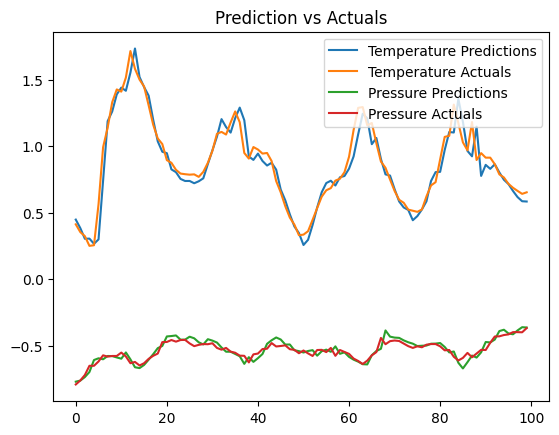

In [174]:
standardized_predict_plot(model=multi_conv1d_best, X=X3_test, y=y3_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,0.423631,0.334877,0.642635,0.655656
1,0.206513,0.207938,0.691465,0.688397
2,0.117433,0.167976,0.716174,0.682334
3,0.106403,0.062193,0.705624,0.682334
4,0.006493,0.065719,0.663359,0.717500
...,...,...,...,...
4995,0.904718,0.849685,-0.921733,-0.951081
4996,0.767742,0.755656,-0.915245,-0.914702
4997,0.692962,0.666329,-0.890356,-0.880748
4998,0.624838,0.537039,-0.854061,-0.829818


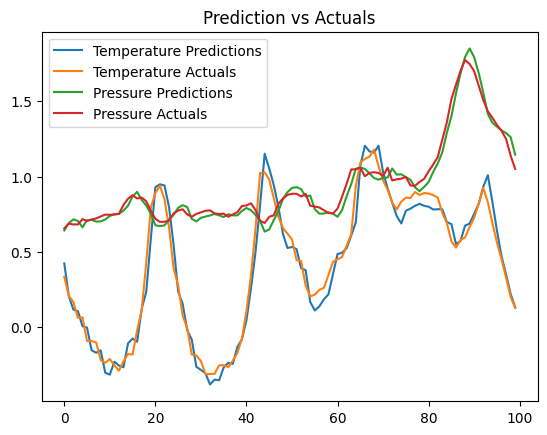

In [175]:
standardized_predict_plot(model=multi_conv1d_best, X=X3_val, y=y3_val)

In [176]:
def post_process_temp(arr):
    arr = (arr*temp_training_std3) + temp_training_mean3
    return arr

def post_process_p(arr):
    arr = (arr*p_training_std3) + p_training_mean3
    return arr

In [177]:
def original_vals_predict_plot(model, X, y, start=0, end=100, title='Prediction vs Actuals'):
    predictions = model.predict(X)
    p_preds, temp_preds = post_process_p(predictions[:, 0]), post_process_temp(predictions[:, 1])
    p_actuals, temp_actuals = post_process_p(y[:, 0]), post_process_temp(y[:, 1])
    df = pd.DataFrame(
        data={
            'Temperature Predictions': temp_preds,
            'Temperature Actuals':temp_actuals,
            'Pressure Predictions': p_preds,
            'Pressure Actuals': p_actuals
        }
    )

    df.iloc[start:end].plot(title=title)
    return df

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,13.232574,12.93,982.604797,982.43
1,12.685183,12.43,982.671387,982.68
2,12.003138,12.17,982.889465,983.02
3,12.015194,11.55,983.204529,983.59
4,11.681170,11.59,983.948914,983.59
...,...,...,...,...
5079,-1.166981,-0.98,1002.393433,1002.18
5080,-1.531001,-1.40,1002.196594,1001.40
5081,-1.426424,-2.75,1001.383606,1001.19
5082,-2.667205,-2.89,1000.690918,1000.65


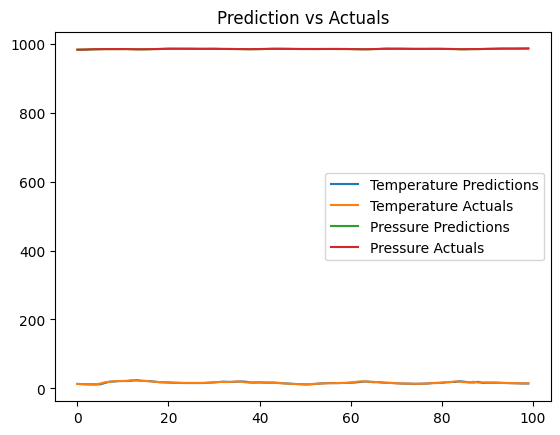

In [178]:
original_vals_predict_plot(model=multi_conv1d_best, X=X3_test, y=y3_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,13.025121,12.27,994.272644,994.38
1,11.177878,11.19,994.675354,994.65
2,10.419987,10.85,994.879089,994.60
3,10.326143,9.95,994.792114,994.60
4,9.476104,9.98,994.443542,994.89
...,...,...,...,...
4995,17.118223,16.65,981.372070,981.13
4996,15.952826,15.85,981.425537,981.43
4997,15.316595,15.09,981.630798,981.71
4998,14.736998,13.99,981.930115,982.13


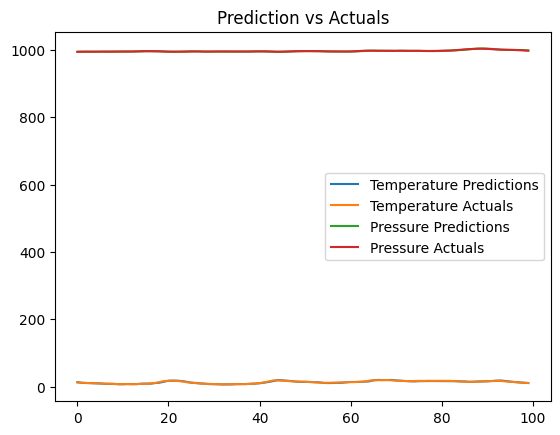

In [179]:
original_vals_predict_plot(model=multi_conv1d_best, X=X3_val, y=y3_val)

## Using GRU

All the data preparation is already done in the multi-var prediction using conv1d

### Creating GRU layer

In [182]:
multi_gru = Sequential()
multi_gru.add(InputLayer((7,6)))
multi_gru.add(GRU(units=64, activation="relu"))
multi_gru.add(Dense(8, "relu"))
multi_gru.add(Dense(2, "linear"))
multi_gru.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,362 (56.10 KB)

 Trainable params: 14,362 (56.10 KB)

 Non-trainable params: 0 (0.00 B)

### Saving best model and compiling
Saving best model and compiling GRU layered model

In [183]:
multi_gru_checkpoint = ModelCheckpoint("../model/best_multi_gru.keras", save_best_only=True)
multi_gru.compile(loss=MeanSquaredError(), metrics=[RootMeanSquaredError()], optimizer=Adam(learning_rate=0.0001))

### Training

In [184]:
multi_gru_hist = multi_gru.fit(
    X3_train,
    y3_train,
    validation_data=(X3_val, y3_val),
    epochs=10,
    callbacks=[multi_gru_checkpoint]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 0.4303 - root_mean_squared_error: 0.6281 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0897
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0086 - root_mean_squared_error: 0.0929 - val_loss: 0.0059 - val_root_mean_squared_error: 0.0769
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0070 - root_mean_squared_error: 0.0838 - val_loss: 0.0064 - val_root_mean_squared_error: 0.0800
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0064 - root_mean_squared_error: 0.0802 - val_loss: 0.0046 - val_root_mean_squared_error: 0.0680
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0062 - root_mean_squared_error: 0.0786 - val_loss: 0.0047 - val_root_mean_squared_error: 0.0684
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0056 - root_mean_squared_error: 0.0749 - val_loss: 0.0045 - val_root_mean_squared_error: 0.0668
Epoch 7/10
1875/1875 ━━━━━━━

### Loading saved model

In [186]:
best_multi_gru = load_model("../model/best_multi_gru.keras")

### Plotting and predicting

159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,0.404221,0.412451,-0.782689,-0.793439
1,0.352728,0.353683,-0.770650,-0.763123
2,0.296495,0.323123,-0.739653,-0.721893
3,0.289232,0.250251,-0.685391,-0.652773
4,0.244534,0.254952,-0.600368,-0.652773
...,...,...,...,...
5079,-1.290106,-1.222477,1.609607,1.601508
5080,-1.323678,-1.271843,1.582853,1.506923
5081,-1.329508,-1.430516,1.476102,1.481458
5082,-1.508653,-1.446971,1.423355,1.415976


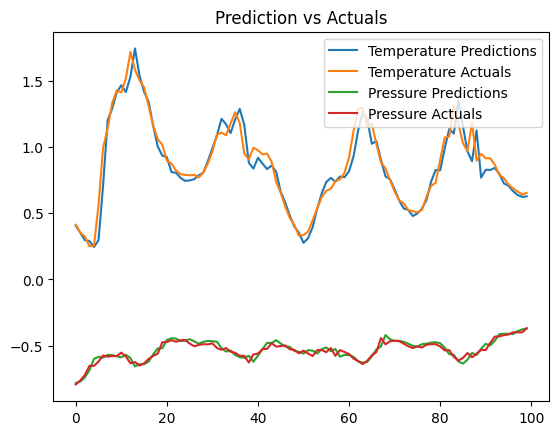

In [187]:
standardized_predict_plot(model=best_multi_gru, X=X3_test, y=y3_test)

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,12.859980,12.93,982.518677,982.43
1,12.421876,12.43,982.617981,982.68
2,11.943443,12.17,982.873596,983.02
3,11.881653,11.55,983.321045,983.59
4,11.501360,11.59,984.022217,983.59
...,...,...,...,...
5079,-1.555383,-0.98,1002.246826,1002.18
5080,-1.841014,-1.40,1002.026184,1001.40
5081,-1.890617,-2.75,1001.145874,1001.19
5082,-3.414784,-2.89,1000.710876,1000.65


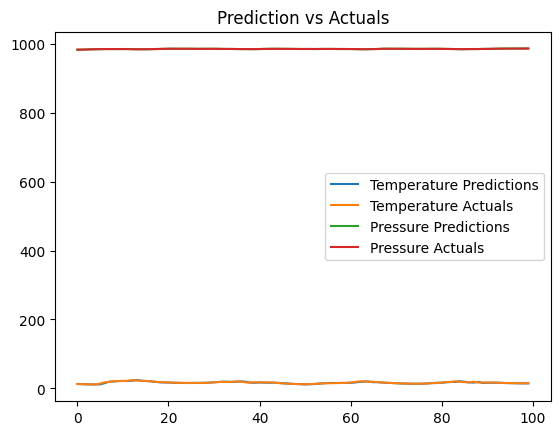

In [188]:
original_vals_predict_plot(model=best_multi_gru, X=X3_test, y=y3_test)

# Using Granger-causality matrix

In [189]:
from statsmodels.tsa.stattools import grangercausalitytests
from pandas import DataFrame

def granger_causality_matrix(data: DataFrame, maxlag):
    variables = data.columns
    granger_matrix = DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)

    for col in variables:
        for row in variables:
            if row != col:
                test_result = grangercausalitytests(data[[row, col]], maxlag=maxlag, verbose=False)
                # Store p-value for the smallest lag where causality exists
                p_values = [round(test_result[i+1][0]['ssr_ftest'][1], 4) for i in range(maxlag)]
                granger_matrix.loc[row, col] = np.min(p_values)
            else:
                granger_matrix.loc[row, col] = np.nan  # Causality with itself is not relevant

    return granger_matrix

The provided function, granger_causality_matrix, creates a matrix that represents the Granger causality relationships between multiple variables in a dataset. Here's an easy explanation:

## Key Concepts:
### Granger Causality:
* A statistical hypothesis test used to determine whether one time series can predict another.
* If series `A` "Granger-causes" series `B`, the past values of `A` contain information that helps predict `B` better than just using `B`'s past values alone.

### Purpose of the Function:
* To test whether each variable in a dataset Granger-causes others.
* The result is a matrix where each cell contains the smallest p-value from the Granger causality test between two variables, indicating how likely it is that one causes the other.

## Step-by-Step Explanation of the Code:
### Inputs:
 - `data`: A DataFrame where columns are time series variables.
 - `maxlag`: The maximum number of lags to consider in the Granger causality test.

### Variables Setup:
 - `variables`: data.columns: Extracts the names of the variables (columns) in the dataset.
 - `granger_matrix`: An empty square matrix where rows and columns represent the variables, initialized with zeros.

### Testing Relationships:
For each pair of variables (excluding self-pairs):
 - `data[[row, col]]`: Selects the two variables for testing, where row is the potential "cause" and col is the "effect."
 - `grangercausalitytests`: Performs the Granger causality test between the selected pair for lags up to maxlag.
 - `p_values`: Extracts the p-values (significance levels) from the test results for all lags.
 - `np.min(p_values)`: Takes the smallest p-value, representing the strongest evidence of causality.

### Matrix Population:
* Stores the minimum p-value in the matrix cell for `[row, col]`.
* If the variables are the same `(row == col)`, it assigns `NaN` because self-causality is irrelevant.

### Output:
* The result is a `DataFrame` `(granger_matrix)` where:
  - Rows indicate the potential "causing" variable.
  - Columns indicate the "effected" variable.
  - Values represent the minimum p-value of Granger causality tests.

# Further improvements
* Use the granger causality test to find the variables' causality with one another.
* Based on that "causality", you may do a single input/series to predict a causally related series.
* For predicting a series or more than one series, with input(s) as granger-causing relationship, you can pick that series as input(s) in your desired NN layer.

| Platform     | Profile Link                                   |
|--------------|-----------------------------------------------|
| LinkedIn     | [Fawad Awan](https://linkedin.com/in//fawad-awan-893a58171) |
| GitHub       | [JackTheProgrammer](https://github.com/JackTheProgrammer)      |